# Marketing Analytics: Web Traffic Forecast

**Time Series Forecasting with Facebook Prophet**  
Using historical click data from a multi-channel campaign dataset to model traffic trends and generate a 365-day forward forecast with confidence intervals.  
**Dataset:** Multi-Channel Marketing Campaign Dataset (CSV) — campaign-level records across channels, click volume, impressions, ROI, and conversion data.

---

## Objectives

- Extract a daily click time series from campaign-level records
- Validate data completeness before model fitting
- Fit a Facebook Prophet model to capture trend and seasonality
- Generate a 365-day forward forecast with upper and lower confidence bounds
- Visualize the forecast and decompose trend vs. seasonal components

---

**Libraries:** pandas, numpy, matplotlib, seaborn, prophet  
**Data:** `marketing_campaign.csv`

## Libraries

In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
import chardet as cd
import numpy as np
import matplotlib.pyplot as plt

## Data Preparation

The raw dataset contains campaign-level records across multiple channels and metrics. For time series forecasting, only two columns are needed: the date of each record and the click volume recorded on that date. The preparation step extracts those two fields, converts the date column to a proper datetime format, and aggregates by day to produce a clean daily click series ready for modeling.

In [2]:
#Load the data
df = pd.read_csv("marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Initech,Radio,45-54,62,Facebook,0.0310,63.11,21.77,San Diego,German,910,16145,0.04,Youth,2021-01-01
1,2,Umbrella,Influencer,35-44,23,Google Ads,0.1598,158.41,94.40,Chicago,Spanish,503,8809,4.48,Senior,2021-01-01
2,3,Globex,TV,18-24,33,TV,0.0320,280.79,0.00,Los Angeles,French,4789,67917,8.37,Youth,2021-01-01
3,4,Acme Corp,Influencer,45-54,9,Twitter,0.1725,65.60,41.26,Chicago,Spanish,2374,12029,0.35,Youth,2021-01-01
4,5,Umbrella,Influencer,45-54,35,YouTube,0.0729,77.41,71.45,San Diego,French,2327,21084,6.94,Middle Aged,2021-01-01


## Column Selection

With the time series extracted, only the Date and Clicks columns are retained. All other campaign attributes, channel, campaign type, impressions, ROI, are not relevant to the forecasting model and are dropped to keep the dataset focused.

In [3]:
# Extract date and clicks for time series forecasting
traffic = df[['Date', 'Clicks']].copy()
traffic['Date'] = pd.to_datetime(traffic['Date'])
traffic = traffic.groupby('Date')['Clicks'].sum().reset_index()
traffic.head()

,Date,Clicks
0,2021-01-01,55370
1,2021-01-02,73556
2,2021-01-03,48577
3,2021-01-04,68712
4,2021-01-05,66137


In [4]:
traffic.tail()

,Date,Clicks
412,2022-02-17,63821
413,2022-02-18,59571
414,2022-02-19,65124
415,2022-02-20,65823
416,2022-02-21,29430


In [5]:
traffic.describe()

,Date,Clicks
count,417,417.000000
mean,2021-07-28 00:00:00,60807.436451
min,2021-01-01 00:00:00,29430.000000
25%,2021-04-15 00:00:00,56100.000000
50%,2021-07-28 00:00:00,61227.000000
75%,2021-11-09 00:00:00,65575.000000
max,2022-02-21 00:00:00,76942.000000
std,NaN,6897.425622


In [6]:
df.shape

(10000, 16)

## Data Quality Check

Missing dates or null click values in a time series create gaps that can cause a forecasting model to misinterpret trend or seasonality. Verifying completeness at this stage ensures the model receives a continuous, uninterrupted sequence of observations.

In [7]:
traffic.isnull().sum()

Date      0
Clicks    0
dtype: int64

## Statistical Summary

The describe() output gives a view of the click volume distribution, average daily clicks, the minimum and maximum observed, and the spread across the dataset. These figures establish what a typical day looks like in terms of traffic and help calibrate expectations for what the forecast should reasonably project.

In [8]:
traffic.describe()

,Date,Clicks
count,417,417.000000
mean,2021-07-28 00:00:00,60807.436451
min,2021-01-01 00:00:00,29430.000000
25%,2021-04-15 00:00:00,56100.000000
50%,2021-07-28 00:00:00,61227.000000
75%,2021-11-09 00:00:00,65575.000000
max,2022-02-21 00:00:00,76942.000000
std,NaN,6897.425622


In [9]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    417 non-null    datetime64[us]
 1   Clicks  417 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 6.6 KB


In [10]:
traffic.dtypes

Date      datetime64[us]
Clicks             int64
dtype: object

## Prepare for Prophet

Facebook Prophet requires the time series to be structured with exactly two columns: `ds` (the date) and `y` (the value to forecast). The Date and Clicks columns are renamed accordingly before the model is fit.

In [11]:
traffic.columns = ['ds', 'y']

In [12]:
traffic.head()

,ds,y
0,2021-01-01,55370
1,2021-01-02,73556
2,2021-01-03,48577
3,2021-01-04,68712
4,2021-01-05,66137


## Fitting the Forecast Model

Prophet is a time series forecasting library developed by Meta that decomposes a series into trend, seasonality, and holiday components. It is well-suited for this dataset because it handles irregular time series, missing data, and multiple seasonality patterns without requiring manual parameter tuning. The model is fit on the full historical click series, then asked to project 365 days forward.

In [13]:
m = Prophet()
m.fit(traffic)

00:55:10 - cmdstanpy - INFO - Chain [1] start processing


00:55:10 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
777,2023-02-17
778,2023-02-18
779,2023-02-19
780,2023-02-20
781,2023-02-21


In [15]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
777,2023-02-17,59409.954481,50402.228392,67956.982561
778,2023-02-18,59144.716451,50443.313367,67806.519948
779,2023-02-19,58836.247781,49693.487967,67512.750483
780,2023-02-20,58923.673788,50672.980785,67868.614607
781,2023-02-21,58992.016381,50644.017013,68234.335062


The forecast output shows each date (`ds`) alongside three columns: `yhat` (the model's point prediction), `yhat_lower`, and `yhat_upper` (the 80% confidence bounds). The width of that interval reflects how much uncertainty the model assigns to each future date — wider bounds in later periods indicate compounding uncertainty further out in the forecast.

## Forecast Visualization

The visualizations below show three views of the forecast: the raw historical click volume, the Prophet forecast with upper and lower confidence bounds, and a decomposition of the trend and seasonal components. The component plot is particularly useful, it separates the overall growth trajectory from the recurring weekly or annual patterns that drive traffic up or down on a predictable basis.

Text(0, 0.5, 'Traffic')

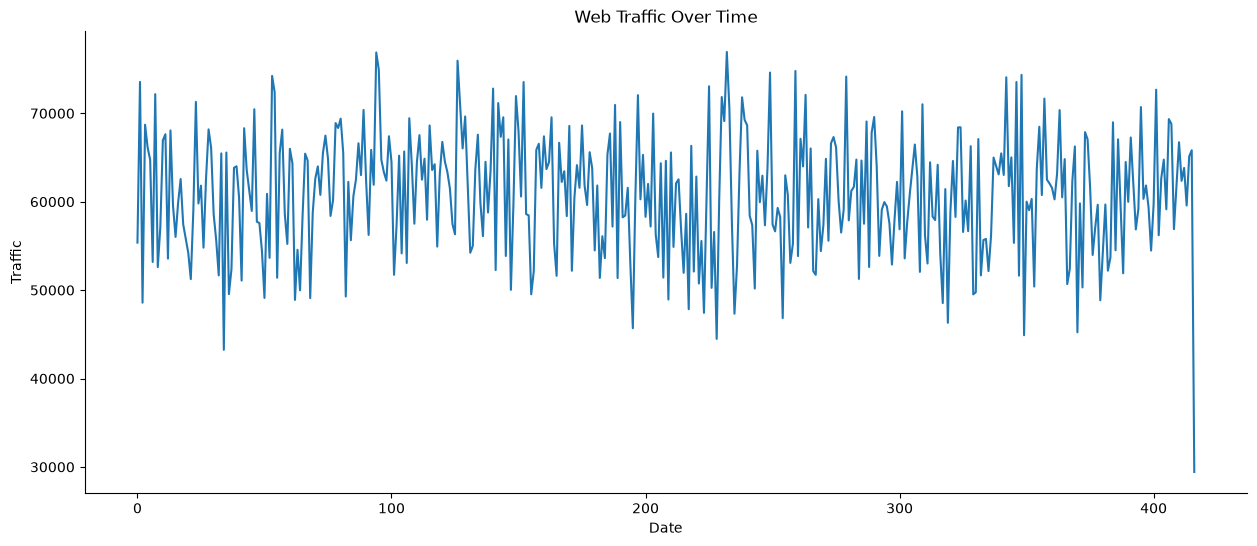

In [16]:
from matplotlib import pyplot as plt
traffic['y'].plot(kind='line', figsize=(15, 6), title='y')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.title('Web Traffic Over Time')
plt.xlabel('Date')
plt.ylabel('Traffic')

Text(64.72222222222221, 0.5, 'Traffic')

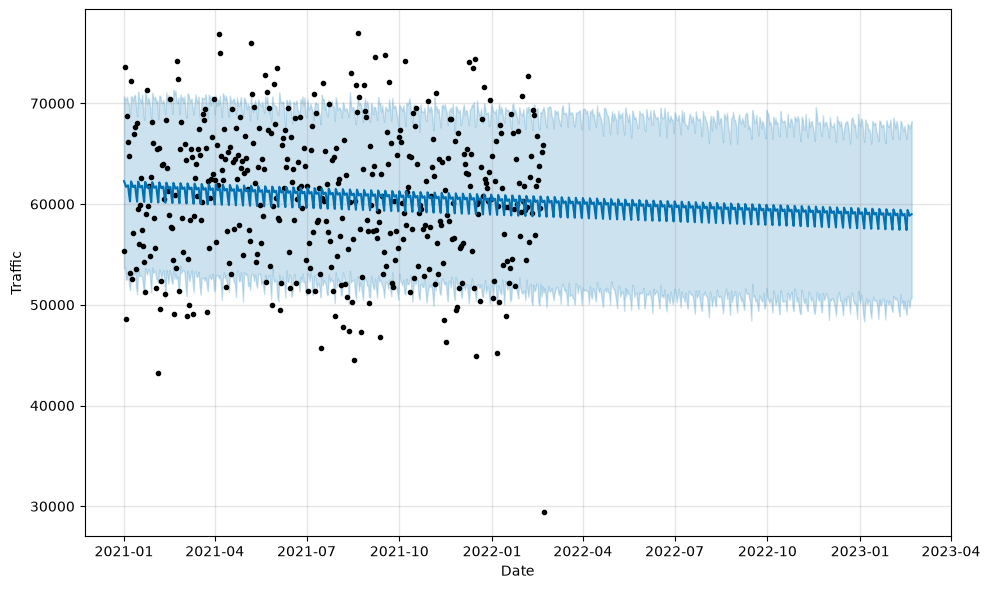

In [17]:
fig1 = m.plot(forecast)

plt.xlabel('Date')
plt.ylabel('Traffic')

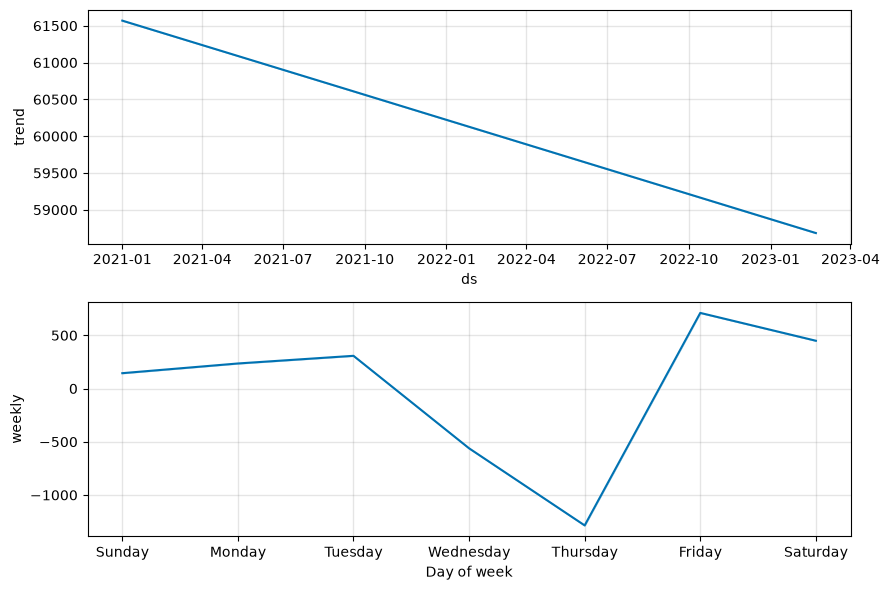

In [18]:
fig2 = m.plot_components(forecast)

In [19]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

Based on the analysis of our current marketing campaign, it's evident that our efforts have maintained a steady trajectory thus far, yielding consistent results. However, a closer examination reveals potential challenges that could lead to a decline in the future.


Campaign metrics such as click-through rates (CTR) and conversion rates have shown stable performance. This indicates that our strategies have resonated with our target audience and generated satisfactory engagement.


Recommendations:

* Diversify Targeting:
    * Expand our audience segments to include demographics or regions that show potential for growth. Conduct thorough market research to identify untapped opportunities.

* Innovate Campaigns:
    * Experiment with new marketing channels or tactics that align with emerging trends. This could include leveraging social media platforms more effectively or investing in content marketing to improve organic reach.

* Customer Engagement:
    * Increase focus on personalized marketing strategies that cater to individual customer preferences. Utilize data analytics to segment our audience more precisely and deliver targeted campaigns that drive engagement and loyalty.


By implementing these recommendations into our strategy, we can mitigate the potential decline in our marketing campaign's effectiveness and position ourselves for sustained growth in the competitive landscape ahead.

